Load the Dataset

In [1]:
from sklearn.datasets import load_iris
import pandas as pd

data = load_iris()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print(X.head())
print(y.head())



   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
0    0
1    0
2    0
3    0
4    0
dtype: int64


In [4]:
df = pd.concat([X, y.rename('target')], axis=1)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Data Visualization

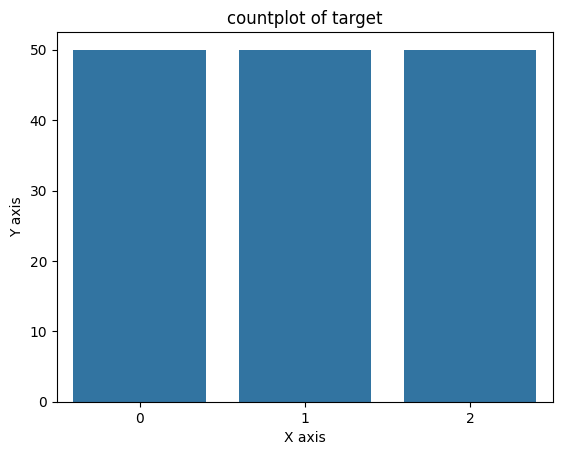

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="target", data=df)

plt.title("countplot of target")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.show()

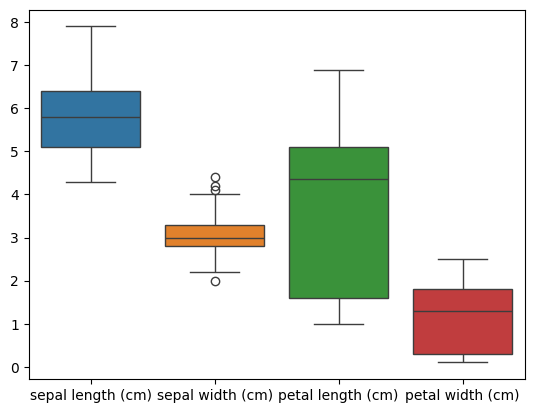

In [7]:
sns.boxplot(data=df.iloc[:, :-1])
plt.show()

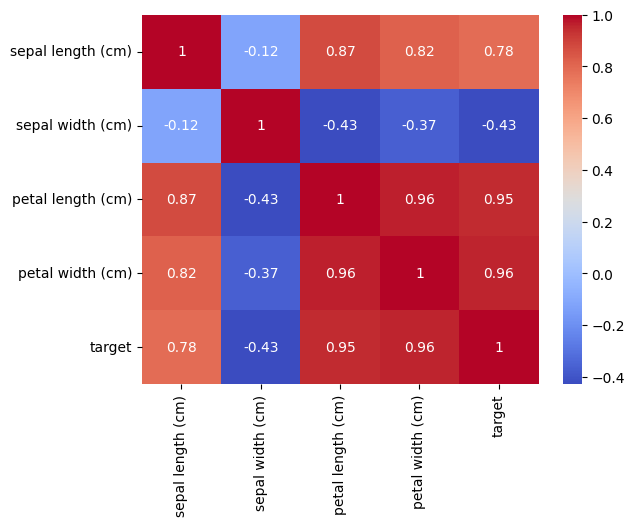

In [9]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

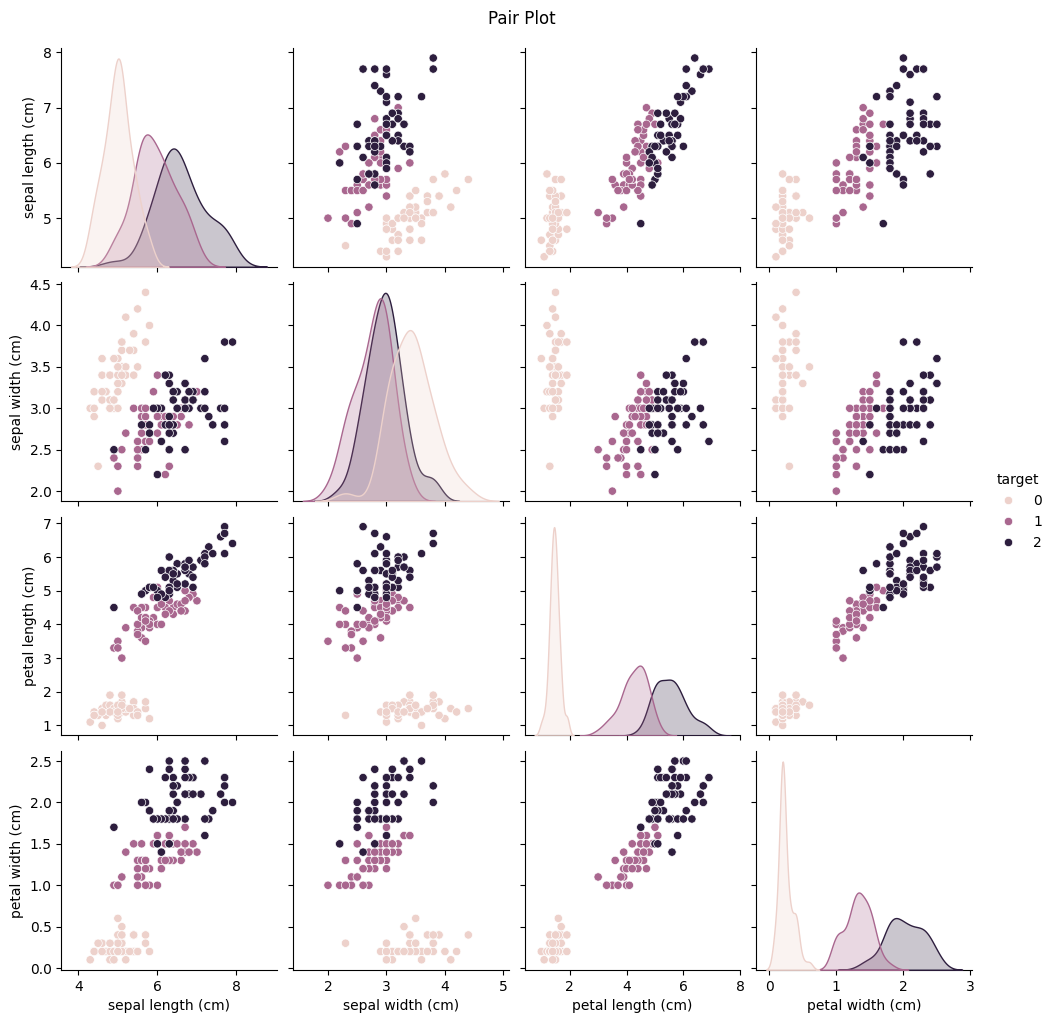

In [10]:
sns.pairplot(
    df,
    vars=[
        "sepal length (cm)",
        "sepal width (cm)",
        "petal length (cm)",
        "petal width (cm)"
    ],
    hue="target"
)

plt.suptitle("Pair Plot", y=1.02)
plt.show()

Data Preprocessing and training - test spilting

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler is a data preprocessing tool used to transform numerical features to a similar scale or range

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Model Training with Logistic,descision Tree ,random forest , SVM and prediction 

In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [14]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [16]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

Model Evalution

In [17]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Accuracy (Decision Tree):", accuracy_score(y_test, y_pred_dt))
print("Accuracy (Random Forest):", accuracy_score(y_test, y_pred_rf))
print("Accuracy (SVM):", accuracy_score(y_test, y_pred_svm))

Accuracy: 1.0
Accuracy (Decision Tree): 1.0
Accuracy (Random Forest): 1.0
Accuracy (SVM): 1.0


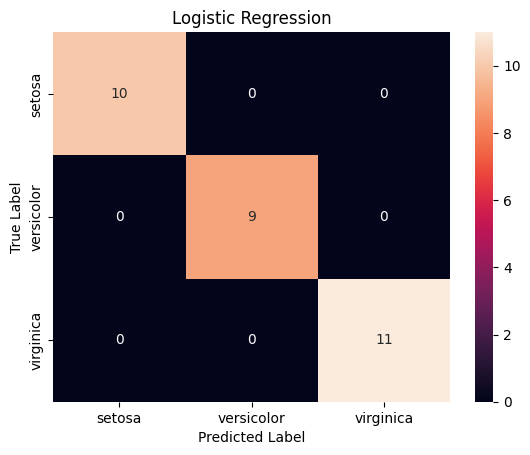

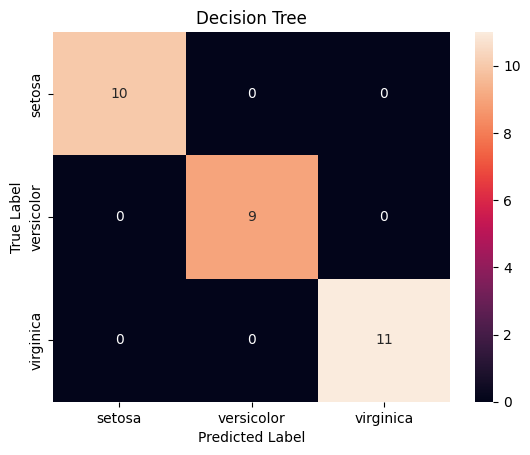

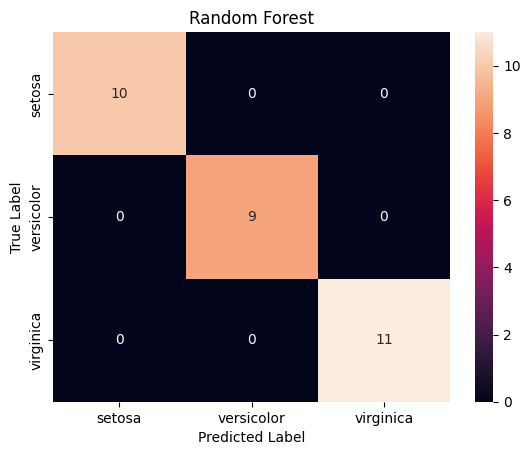

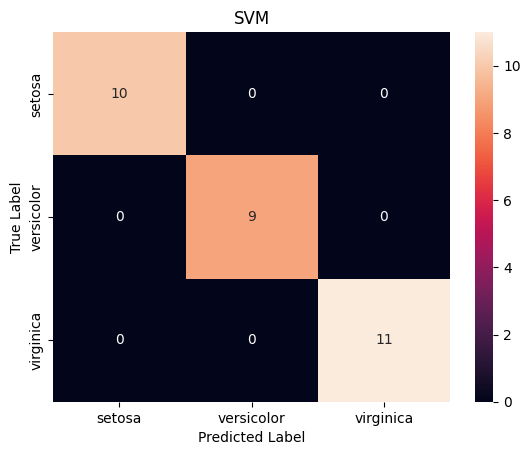

In [ ]:
from sklearn.metrics import confusion_matrix

labels = data.target_names 

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure()
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        xticklabels=labels,
        yticklabels=labels
    )
    
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()

# Calls
plot_cm(y_test, y_pred, "Logistic Regression")
plot_cm(y_test, y_pred_dt, "Decision Tree")
plot_cm(y_test, y_pred_rf, "Random Forest")
plot_cm(y_test, y_pred_svm, "SVM")

In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))
print(classification_report(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy        